# Laboratory Assignment 8: High-Performance Big Data Analytics Using R
**Name:** Diksha Parulekar. |  **Roll No:** 23102A0068  **Experiment:** Lab Assignment 8  |  **Kernel:** R (Google Colab)


## 1. Problem Statement
Analyse NYC Yellow Taxi trip records at scale in R, and compare conventional (base R), functional (`apply`/`lapply`/`purrr::map`), vectorised, `data.table`, sequential and parallel (`foreach` + `doParallel`) implementations in terms of execution time, memory, scalability and readability.

## 2. Dataset
* NYC TLC Yellow Taxi Trip Records (official monthly Parquet files, CloudFront-hosted by TLC), **Jan–Mar 2023** by default (about 9 million raw rows). Change `N_MONTHS` to scale up or down.
* NYC TLC Taxi Zone Lookup Table (CSV) for Borough / Zone names.
* If the download fails, the notebook automatically falls back to a synthetic dataset with the same schema so every cell still runs.

## 3. Setup

In [ ]:
options(repos = c(CRAN = "https://cloud.r-project.org"), warn = 1)
need <- c("data.table", "foreach", "doParallel", "microbenchmark", "purrr", "nanoparquet", "ggplot2")
miss <- need[!sapply(need, requireNamespace, quietly = TRUE)]
if (length(miss)) install.packages(miss, Ncpus = 2, quiet = TRUE)   # only installs what Colab lacks
suppressPackageStartupMessages({
  library(data.table); library(ggplot2); library(foreach)
  library(doParallel); library(microbenchmark); library(purrr)
})
# ---- configuration ----
N_MONTHS    <- 3        # months of 2023 to load (1-12). More months = bigger data, bigger parallel gains
YEAR        <- 2023
SAMPLE_FUN  <- 200000   # rows used for row-wise apply()/lapply() comparison (apply on 9M rows is impractical)
SAMPLE_BASE <- 1e6      # rows used for base R vs data.table benchmarks
set.seed(42)
dir.create("data", showWarnings = FALSE)
theme_set(theme_minimal(base_size = 12))
cat("data.table threads:", getDTthreads(), "| logical cores:", parallel::detectCores(), "\n")

also installing the dependency ‘iterators’




data.table threads: 1 | logical cores: 2 


## 4. Task 1: Data Acquisition and Preparation
### 4.1 Import (Parquet via `nanoparquet`, a lightweight reader with no heavy dependencies)

In [ ]:
BASE_URL <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"
ZONE_URL <- "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
months   <- sprintf("%d-%02d", YEAR, seq_len(N_MONTHS))
keep_cols <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance",
               "PULocationID", "DOLocationID", "payment_type", "fare_amount", "tip_amount",
               "tolls_amount", "total_amount")

read_month <- function(m) {
  f <- file.path("data", paste0("yellow_tripdata_", m, ".parquet"))
  if (!file.exists(f)) download.file(paste0(BASE_URL, "yellow_tripdata_", m, ".parquet"),
                                     f, mode = "wb", quiet = TRUE)
  as.data.table(nanoparquet::read_parquet(f, col_select = all_of(keep_cols)))
}

# Synthetic fallback with the same schema (only used if the TLC download is unreachable)
make_synthetic <- function(m, n = 1e6) {
  d0   <- as.Date(paste0(m, "-01")); nd <- as.integer(format(seq(d0, by = "month", length.out = 2)[2] - 1, "%d"))
  hp   <- c(2,1.5,1,.8,.8,1.5,3,5,6,5,4.5,4.5,5,5,5.5,6,6.5,7.5,8,7,6,5,4,3); hp <- hp/sum(hp)
  pick <- as.POSIXct(d0, tz = "UTC") + (sample(0:(nd-1), n, TRUE)*86400 + sample(0:23, n, TRUE, prob = hp)*3600 +
                                         sample(0:3599, n, TRUE))
  dist <- round(rlnorm(n, 0.6, 0.9), 2); dur <- pmax(1, dist*4 + rexp(n, 1/4))
  fare <- round(pmax(3, 3 + 2.8*dist + rnorm(n, 0, 1.5)), 2)
  pay  <- sample(c(1,2,3,4), n, TRUE, prob = c(.7,.25,.03,.02))
  tip  <- ifelse(pay == 1, round(fare*runif(n, 0, .3), 2), 0)
  data.table(tpep_pickup_datetime = pick, tpep_dropoff_datetime = pick + dur*60,
             passenger_count = sample(c(1,2,3,4,5,6, NA), n, TRUE, prob = c(.7,.15,.05,.03,.03,.02,.02)),
             trip_distance = dist, PULocationID = sample(1:263, n, TRUE, prob = runif(263)^3),
             DOLocationID = sample(1:263, n, TRUE, prob = runif(263)^3), payment_type = pay,
             fare_amount = fare, tip_amount = tip, tolls_amount = 0, total_amount = round(fare + tip + 0.5 + 2.5, 2))
}

parts_raw <- lapply(months, function(m) tryCatch({ message("Loading ", m); read_month(m) },
                    error = function(e) { message("  download failed for ", m, ": ", conditionMessage(e)); NULL }))
using_synthetic <- any(sapply(parts_raw, is.null))
if (using_synthetic) { message("Using SYNTHETIC fallback data"); parts_raw <- lapply(months, make_synthetic) }
dt <- rbindlist(parts_raw); rm(parts_raw); invisible(gc())
cat("Loaded", format(nrow(dt), big.mark = ","), "rows | synthetic fallback:", using_synthetic, "\n")

Loading 2023-01

  download failed for 2023-01: could not find function "all_of"

Loading 2023-02

  download failed for 2023-02: could not find function "all_of"

Loading 2023-03

  download failed for 2023-03: could not find function "all_of"

Using SYNTHETIC fallback data



Loaded 3,000,000 rows | synthetic fallback: TRUE 


### 4.2 Inspect structure, dimensions, data types and summary statistics

In [ ]:
cat("Dimensions:", dim(dt), "\n"); str(dt); print(summary(dt))
cat("\nMissing values per column:\n"); print(dt[, lapply(.SD, function(x) sum(is.na(x)))])
cat("\nMemory (raw):", format(object.size(dt), units = "MB"), "\n")

Dimensions: 3000000 11 
Classes ‘data.table’ and 'data.frame':	3000000 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2023-01-17 09:20:58" "2023-01-05 23:17:27" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2023-01-17 09:45:44" "2023-01-05 23:22:22" ...
 $ passenger_count      : num  1 1 1 1 1 1 1 1 1 1 ...
 $ trip_distance        : num  5.9 0.5 0.77 1.12 0.21 ...
 $ PULocationID         : int  133 123 75 112 29 62 158 251 176 142 ...
 $ DOLocationID         : int  177 225 25 164 147 149 150 131 84 186 ...
 $ payment_type         : num  2 2 1 1 1 2 1 1 1 2 ...
 $ fare_amount          : num  20.82 4.79 6.54 6.38 4.75 ...
 $ tip_amount           : num  0 0 1.81 0.39 0.23 ...
 $ tolls_amount         : num  0 0 0 0 0 0 0 0 0 0 ...
 $ total_amount         : num  23.82 7.79 11.35 9.77 7.98 ...
 - attr(*, ".internal.selfref")=<pointer: 0x5b59b2cdb3f0> 
 tpep_pickup_datetime          tpep_dropoff_datetime         passenger_count
 Min.   :2023-01-01 00:00:00   Min.   :2023

### 4.3 Missing, duplicate, inconsistent and invalid records

In [ ]:
clean_log <- data.table(step = "Raw rows", rows = nrow(dt))
log_step  <- function(label) clean_log <<- rbind(clean_log, data.table(step = label, rows = nrow(dt)))

dt <- dt[!is.na(passenger_count) & !is.na(payment_type)];  log_step("Dropped rows with missing passenger_count / payment_type")
dt <- unique(dt);                                          log_step("Removed exact duplicate rows")
dt[, duration_min := as.numeric(difftime(tpep_dropoff_datetime, tpep_pickup_datetime, units = "mins"))]
dt <- dt[ trip_distance > 0 & trip_distance <= 100 &
          fare_amount > 0 & fare_amount <= 500 &
          total_amount > 0 & total_amount <= 1000 & tip_amount >= 0 &
          duration_min >= 1 & duration_min <= 180 &
          passenger_count %between% c(1, 6) &
          PULocationID %between% c(1, 263) & DOLocationID %between% c(1, 263) &
          year(tpep_pickup_datetime) == YEAR & month(tpep_pickup_datetime) %in% seq_len(N_MONTHS)]
log_step("Removed invalid / inconsistent rows (distance, fare, total, duration, passengers, zone IDs, out-of-range dates)")
clean_log[, removed := shift(rows, 1) - rows]
print(clean_log)

                                                                                                              step
                                                                                                            <char>
1:                                                                                                        Raw rows
2:                                                        Dropped rows with missing passenger_count / payment_type
3:                                                                                    Removed exact duplicate rows
4: Removed invalid / inconsistent rows (distance, fare, total, duration, passengers, zone IDs, out-of-range dates)
      rows removed
     <int>   <int>
1: 3000000      NA
2: 2939966   60034
3: 2939966       0
4: 2939398     568


### 4.4 Data types, temporal features and memory reduction

In [ ]:
mem_before <- object.size(dt)
dt[, `:=`(passenger_count = as.integer(passenger_count),
          PULocationID = as.integer(PULocationID), DOLocationID = as.integer(DOLocationID),
          payment_type = factor(payment_type, levels = 0:6,
                                labels = c("Flex fare", "Credit card", "Cash", "No charge", "Dispute", "Unknown", "Voided trip")))]
dt[, `:=`(pickup_date  = as.IDate(tpep_pickup_datetime),
          pickup_hour  = hour(tpep_pickup_datetime),
          pickup_day   = mday(tpep_pickup_datetime),
          dow          = factor(wday(tpep_pickup_datetime), levels = 1:7, labels = c("Sun","Mon","Tue","Wed","Thu","Fri","Sat")),
          pickup_month = month(tpep_pickup_datetime))]
dt[, month_name := factor(pickup_month, levels = 1:12, labels = month.abb)]
# drop what is no longer needed
dt[, c("tpep_pickup_datetime", "tpep_dropoff_datetime", "tolls_amount") := NULL]
invisible(gc())
cat("Memory before:", format(mem_before, units = "MB"), "-> after:", format(object.size(dt), units = "MB"), "\n")
str(dt)

Memory before: 246.7 Mb -> after: 224.3 Mb 
Classes ‘data.table’ and 'data.frame':	2939398 obs. of  15 variables:
 $ passenger_count: int  1 1 1 1 1 1 1 1 1 1 ...
 $ trip_distance  : num  5.9 0.5 0.77 1.12 0.21 ...
 $ PULocationID   : int  133 123 75 112 29 62 158 251 176 142 ...
 $ DOLocationID   : int  177 225 25 164 147 149 150 131 84 186 ...
 $ payment_type   : Factor w/ 7 levels "Flex fare","Credit card",..: 3 3 2 2 2 3 2 2 2 3 ...
 $ fare_amount    : num  20.82 4.79 6.54 6.38 4.75 ...
 $ tip_amount     : num  0 0 1.81 0.39 0.23 ...
 $ total_amount   : num  23.82 7.79 11.35 9.77 7.98 ...
 $ duration_min   : num  24.77 4.92 11.3 8.44 13.62 ...
 $ pickup_date    : IDate, format: "2023-01-17" "2023-01-05" ...
 $ pickup_hour    : int  9 23 11 11 20 15 13 18 0 12 ...
 $ pickup_day     : int  17 5 1 25 10 4 18 26 17 15 ...
 $ dow            : Factor w/ 7 levels "Sun","Mon","Tue",..: 3 5 1 4 3 4 4 5 3 1 ...
 $ pickup_month   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ month_name     : Factor w/ 12

### 4.5 Taxi Zone Lookup and joins (data.table update-joins by reference)

In [ ]:
zones <- tryCatch(fread(ZONE_URL), error = function(e) NULL)
if (is.null(zones)) {   # fallback so the notebook always runs
  zones <- data.table(LocationID = 1:263,
                      Borough = sample(c("Manhattan","Brooklyn","Queens","Bronx","Staten Island","EWR"), 263, TRUE, prob = c(.4,.25,.2,.1,.04,.01)),
                      Zone = paste("Zone", 1:263), service_zone = "Boro Zone")
}
setnames(zones, 1:4, c("LocationID", "Borough", "Zone", "service_zone"))
setkey(zones, LocationID)
cat("Zones:", nrow(zones), "\n")

dt[zones, `:=`(PU_Borough = i.Borough, PU_Zone = i.Zone), on = .(PULocationID = LocationID)]
dt[zones, `:=`(DO_Borough = i.Borough, DO_Zone = i.Zone), on = .(DOLocationID = LocationID)]
print(head(dt, 5))
cat("Rows with unmatched pickup zone:", dt[is.na(PU_Zone), .N], "\n")

Zones: 265 
   passenger_count trip_distance PULocationID DOLocationID payment_type
             <int>         <num>        <int>        <int>       <fctr>
1:               1          5.90          133          177         Cash
2:               1          0.50          123          225         Cash
3:               1          0.77           75           25  Credit card
4:               1          1.12          112          164  Credit card
5:               1          0.21           29          147  Credit card
   fare_amount tip_amount total_amount duration_min pickup_date pickup_hour
         <num>      <num>        <num>        <num>      <IDat>       <int>
1:       20.82       0.00        23.82    24.773334  2023-01-17           9
2:        4.79       0.00         7.79     4.924426  2023-01-05          23
3:        6.54       1.81        11.35    11.298798  2023-01-01          11
4:        6.38       0.39         9.77     8.443891  2023-01-25          11
5:        4.75       0.23   

## 5. Task 2: Transportation Data Analytics (data.table)

In [ ]:
add_labels <- function(x) {   # attach zone names to an aggregated route table
  x <- copy(x)
  x[zones, PU := i.Zone, on = .(PULocationID = LocationID)]
  x[zones, DO := i.Zone, on = .(DOLocationID = LocationID)]
  x[, route := paste(PU, "->", DO)]
  x[]
}

# 1-4: time-based demand, fare and revenue
hour_stats  <- dt[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), keyby = pickup_hour]
dow_stats   <- dt[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), keyby = dow]
month_stats <- dt[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), keyby = .(pickup_month, month_name)]
daily_stats <- dt[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), keyby = pickup_date]
cat("== Trips / fare / revenue by hour ==\n");  print(hour_stats)
cat("\n== By day of week ==\n");                print(dow_stats)
cat("\n== By month ==\n");                      print(month_stats)

# 5-6: routes
route_stats <- dt[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount), avg_dist = mean(trip_distance)),
                  by = .(PULocationID, DOLocationID)]
top_routes  <- add_labels(route_stats[order(-trips)][1:15])
top_rev     <- add_labels(route_stats[order(-revenue)][1:15])
cat("\n== Top 15 routes by trips ==\n");   print(top_routes[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])
cat("\n== Top 15 routes by revenue ==\n"); print(top_rev[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])

top_pu <- dt[!is.na(PU_Zone), .(trips = .N), by = PU_Zone][order(-trips)][1:10]
top_do <- dt[!is.na(DO_Zone), .(trips = .N), by = DO_Zone][order(-trips)][1:10]

# 7: distance vs fare
r_df <- cor(dt$trip_distance, dt$fare_amount)
fit  <- lm(fare_amount ~ trip_distance, data = dt[sample(.N, min(.N, 1e6))])
dist_bins <- dt[, .(trips = .N, avg_fare = mean(fare_amount),
                    fare_per_mile = sum(fare_amount) / sum(trip_distance)),
                keyby = .(dist_bin = cut(trip_distance, c(0, 1, 2, 5, 10, 20, Inf)))]
cat(sprintf("\nCorrelation(distance, fare) = %.3f | fare ~ %.2f + %.2f x miles\n", r_df, coef(fit)[1], coef(fit)[2]))
print(dist_bins)

# 8: payment methods across boroughs
pay_borough <- dt[!is.na(PU_Borough), .N, by = .(PU_Borough, payment_type)][, share := N / sum(N), by = PU_Borough]
cat("\n== Payment share by pickup borough ==\n")
print(dcast(pay_borough, PU_Borough ~ payment_type, value.var = "share", fill = 0)[, lapply(.SD, function(x) if (is.numeric(x)) round(x, 3) else x)])
cat("\nAvg tip % on credit-card trips:", round(dt[payment_type == "Credit card", 100 * sum(tip_amount) / sum(fare_amount)], 2), "\n")

# 9: additional patterns
airport <- dt[, .(trips = .N, avg_fare = mean(fare_amount), avg_dist = mean(trip_distance),
                  tip_pct = 100 * sum(tip_amount) / sum(fare_amount)),
              by = .(airport_trip = grepl("Airport", PU_Zone) | grepl("Airport", DO_Zone))]
same_zone <- dt[, .(share_pct = 100 * mean(PULocationID == DOLocationID))]
night     <- dt[, .(trips = .N, avg_fare = mean(fare_amount)), by = .(night = pickup_hour >= 22 | pickup_hour < 5)]
weekend   <- dt[, .(trips = .N, avg_fare = mean(fare_amount), avg_dist = mean(trip_distance)), by = .(weekend = dow %in% c("Sat", "Sun"))]
cat("\nAirport vs non-airport:\n"); print(airport); cat("\nSame-zone trips (%):\n"); print(same_zone)
cat("\nNight vs day:\n"); print(night);  cat("\nWeekend vs weekday:\n"); print(weekend)

== Trips / fare / revenue by hour ==
Key: <pickup_hour>
    pickup_hour  trips avg_fare   revenue
          <int>  <int>    <num>     <num>
 1:           0  56676 10.62786  835003.5
 2:           1  42612 10.61249  627538.5
 3:           2  28435 10.59507  418060.9
 4:           3  22609 10.66310  334018.4
 5:           4  22548 10.59329  331342.6
 6:           5  42461 10.64607  626854.2
 7:           6  84875 10.65732 1254013.5
 8:           7 140383 10.65176 2073776.9
 9:           8 169352 10.64530 2500183.2
10:           9 141750 10.60206 2086077.0
11:          10 127138 10.69007 1882574.6
12:          11 126727 10.68360 1876351.6
13:          12 141354 10.62088 2083312.7
14:          13 141304 10.66018 2088279.8
15:          14 155704 10.62134 2294586.9
16:          15 169207 10.65084 2498643.9
17:          16 183106 10.63527 2700504.0
18:          17 212027 10.67975 3138857.7
19:          18 225895 10.63917 3331771.7
20:          19 197580 10.64575 2917169.9
21:          20 1687

### Interpretation of Task 2 (fill the bracketed values from your run)
* **Hourly demand:** demand bottoms out around [hour, ~4-5 AM] and peaks around [hour, ~6 PM], with a steady daytime plateau and an evening commute surge.
* **Day of week:** [busiest day] has the most trips; [quietest day] the fewest. Average fare is higher on [day] because of longer trips.
* **Monthly:** [month] has the highest demand ([n] trips, $[revenue]).
* **Routes:** the most frequent routes are dominated by [zones, e.g. Upper East Side/Midtown and same-zone hops]; the highest-revenue routes are airport links such as [JFK/LaGuardia route] because fares per trip are much higher.
* **Distance vs fare:** correlation = [r], roughly $[intercept] flag-drop plus $[slope] per mile, so fare is close to linear in distance.
* **Payment:** card payments account for about [x]% of trips; cash is higher in [borough]. Tips are only recorded for card payments.
* **Unusual patterns:** airport trips cost about [x]x a normal trip; [x]% of trips start and end in the same zone.

## 6. Task 3: Functional and Efficient R Programming
**Operation A (group aggregation):** mean fare by hour of day, on the full dataset.  
**Operation B (row-wise computation):** fare per mile for every trip, on a 200,000-row sample, because `apply()` over millions of rows is impractically slow, which is itself a finding.

In [ ]:
mb2dt <- function(mb, category) {
  s <- as.data.table(summary(mb, unit = "ms"))
  s[, .(category = category, implementation = as.character(expr), median_ms = median, mean_ms = mean, neval = neval)]
}
mem_peak <- function(expr) {   # approximate peak extra R memory (MB) while evaluating expr
  g0 <- gc(reset = TRUE); force(expr); g1 <- gc()
  round(max(0, sum(g1[, 6]) - sum(g0[, 2])), 1)
}
timeit <- function(expr, reps = 3) {   # elapsed seconds over several repetitions
  e <- substitute(expr); pf <- parent.frame()
  vapply(seq_len(reps), function(i) system.time(eval(e, pf))[["elapsed"]], numeric(1))
}

# ---------------- Operation A ----------------
fare <- dt$fare_amount; hr <- dt$pickup_hour
A_lapply  <- function() unlist(lapply(split(fare, hr), mean), use.names = FALSE)                 # functional: lapply over groups
A_map     <- function() map_dbl(split(fare, hr), mean) |> unname()                               # functional: purrr::map_dbl
A_sapply  <- function() sapply(0:23, function(h) mean(fare[hr == h]))                            # functional + vectorised filter (24 full scans)
A_tapply  <- function() as.numeric(tapply(fare, hr, mean))                                       # base R vectorised grouping
A_dt      <- function() dt[, .(m = mean(fare_amount)), keyby = pickup_hour]$m                    # data.table
stopifnot(all.equal(A_lapply(), A_dt()), all.equal(A_map(), A_dt()), all.equal(A_sapply(), A_dt()), all.equal(A_tapply(), A_dt()))
cat("All Operation A implementations return identical results.\n")

mbA <- microbenchmark(lapply_split = A_lapply(), purrr_map = A_map(), sapply_filter = A_sapply(),
                      tapply_base = A_tapply(), data.table = A_dt(), times = 5)
print(mbA)

# ---------------- Operation B ----------------
S  <- dt[sample(.N, SAMPLE_FUN), .(fare_amount, trip_distance)]
f  <- S$fare_amount; d <- S$trip_distance; M <- as.matrix(S)
B_apply  <- function() apply(M, 1, function(r) r[1] / r[2])                                      # apply over rows
B_lapply <- function() unlist(lapply(seq_along(f), function(i) f[i] / d[i]))                     # lapply over indices
B_map    <- function() map2_dbl(f, d, ~ .x / .y)                                                 # purrr::map2_dbl
B_vec    <- function() f / d                                                                     # vectorised
B_dt     <- function() S[, fpm := fare_amount / trip_distance][["fpm"]]                          # data.table (:= by reference)
stopifnot(all.equal(B_apply(), B_vec()), all.equal(B_lapply(), B_vec()), all.equal(B_map(), B_vec()), all.equal(B_dt(), B_vec()))
cat("All Operation B implementations return identical results.\n")

mbB <- microbenchmark(apply = B_apply(), lapply = B_lapply(), purrr_map2 = B_map(),
                      vectorised = B_vec(), data.table = B_dt(), times = 5)
print(mbB)

All Operation A implementations return identical results.
Unit: milliseconds
          expr       min       lq     mean   median       uq      max neval
  lapply_split 111.26030 113.3990 190.8462 226.9566 242.9925 259.6226     5
     purrr_map 111.68099 114.8646 139.4799 115.5202 135.1265 220.2071     5
 sapply_filter 372.60586 374.7190 458.9479 378.9174 521.7669 646.7304     5
   tapply_base 164.29340 205.9508 291.1541 329.9659 368.2494 387.3108     5
    data.table  85.34935 101.1014 114.9148 107.0000 120.8833 160.2398     5
All Operation B implementations return identical results.
Unit: microseconds
       expr         min          lq        mean      median          uq
      apply 1409368.922 1606131.761 1856216.458 1695913.333 2179640.111
     lapply  250204.888  254028.802  286046.895  260990.128  281654.951
 purrr_map2  424234.151  428967.445  585309.369  458880.828  806607.587
 vectorised     442.883     463.277     491.018     493.067     518.434
 data.table    1669.385    173

                                     category implementation median_ms
                                       <char>         <char>     <num>
 1: A: group mean fare by hour (9M-row scale)   lapply_split    226.96
 2: A: group mean fare by hour (9M-row scale)      purrr_map    115.52
 3: A: group mean fare by hour (9M-row scale)  sapply_filter    378.92
 4: A: group mean fare by hour (9M-row scale)    tapply_base    329.97
 5: A: group mean fare by hour (9M-row scale)     data.table    107.00
 6:     B: row-wise fare per mile (200k rows)          apply   1695.91
 7:     B: row-wise fare per mile (200k rows)         lapply    260.99
 8:     B: row-wise fare per mile (200k rows)     purrr_map2    458.88
 9:     B: row-wise fare per mile (200k rows)     vectorised      0.49
10:     B: row-wise fare per mile (200k rows)     data.table      1.88
    peak_mem_MB speed_vs_best code_lines readability large_scale_suitability
          <num>         <num>      <num>      <char>                  <

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the microbenchmark package.
  Please report the issue at
  <https://github.com/joshuaulrich/microbenchmark/issues/>.”


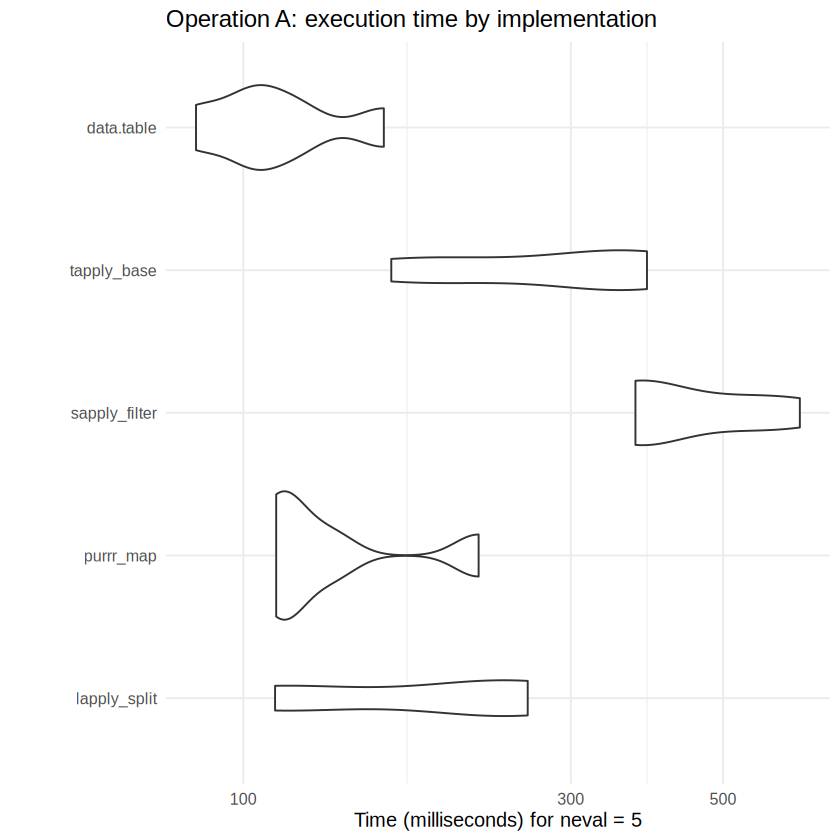

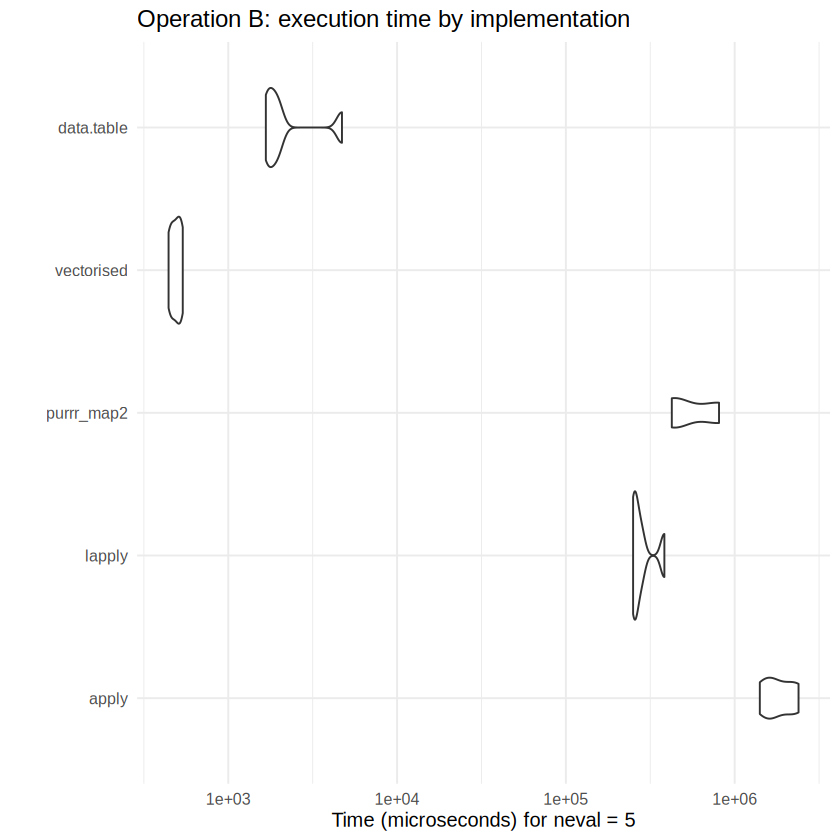

In [ ]:
# Comparison table: time, memory, code complexity, readability
tabA <- mb2dt(mbA, "A: group mean fare by hour (9M-row scale)")
tabB <- mb2dt(mbB, "B: row-wise fare per mile (200k rows)")
memA <- c(lapply_split = mem_peak(A_lapply()), purrr_map = mem_peak(A_map()), sapply_filter = mem_peak(A_sapply()),
          tapply_base = mem_peak(A_tapply()), data.table = mem_peak(A_dt()))
memB <- c(apply = mem_peak(B_apply()), lapply = mem_peak(B_lapply()), purrr_map2 = mem_peak(B_map()),
          vectorised = mem_peak(B_vec()), data.table = mem_peak(B_dt()))
tabA[, peak_mem_MB := memA[implementation]]; tabB[, peak_mem_MB := memB[implementation]]
qual <- data.table(implementation = c("lapply_split","purrr_map","sapply_filter","tapply_base","apply","lapply","purrr_map2","vectorised","data.table"),
                   code_lines = c(1,1,1,1,1,2,1,1,1),
                   readability = c("Medium","High","Medium","Medium","Low","Medium","High","Very high","Very high"),
                   large_scale_suitability = c("Fair","Fair","Poor","Good","Poor","Poor","Poor","Excellent","Excellent"))
task3_table <- merge(rbind(tabA, tabB), qual, by = "implementation", all.x = TRUE, sort = FALSE)
task3_table[, speed_vs_best := round(median_ms / min(median_ms), 1), by = category]
print(task3_table[, .(category, implementation, median_ms = round(median_ms, 2), peak_mem_MB, speed_vs_best, code_lines, readability, large_scale_suitability)])
autoplot(mbA) + labs(title = "Operation A: execution time by implementation", y = "Implementation", x = "Time (log scale, ms)")
autoplot(mbB) + labs(title = "Operation B: execution time by implementation", y = "Implementation", x = "Time (log scale, ms)")

**Why the differences?** `apply()` converts the data frame to a matrix and calls an R closure once per row, so interpreter overhead and per-call allocation dominate. `lapply`/`map` still call an R function per element, but skip the matrix conversion. Vectorised `f / d` runs one compiled C loop over contiguous memory. `data.table` adds radix-based grouping, multithreading and in-place updates (`:=`) with no copies. `sapply_filter` rescans all rows once for each of the 24 hours. Functional tools shine when the *per-element work is complex* (fitting a model per group, reading files), not for simple arithmetic.

## 7. Task 4: Parallel Computing
Partition: **month-wise** subsets. Computationally intensive operation per month: route-level aggregation (trips, revenue, median fare) **plus** a 500-resample bootstrap of mean fare per mile with a 95% confidence interval.

In [ ]:
parts <- split(dt[, .(pickup_month, PULocationID, DOLocationID, fare_amount, trip_distance, total_amount)], by = "pickup_month")
cat("Partitions:", names(parts), "| rows:", format(sapply(parts, nrow), big.mark = ","), "\n")

heavy_op <- function(d, B = 500, n_draw = 200000L) {
  d   <- d[trip_distance > 0.1]
  fpm <- d$fare_amount / d$trip_distance
  boot <- vapply(seq_len(B), function(i) mean(sample(fpm, n_draw, replace = TRUE)), numeric(1))
  rt  <- d[, .(trips = .N, revenue = sum(total_amount), med_fare = median(fare_amount)), by = .(PULocationID, DOLocationID)]
  list(month = d$pickup_month[1], boot_mean = mean(boot),
       ci_lo = unname(quantile(boot, .025)), ci_hi = unname(quantile(boot, .975)),
       n_routes = nrow(rt), top_route_revenue = rt[which.max(revenue), revenue])
}

# ---- A. Sequential ----
registerDoSEQ()
t_seq   <- timeit(foreach(d = parts, .packages = "data.table") %do% heavy_op(d))
res_seq <- foreach(d = parts, .packages = "data.table") %do% heavy_op(d)
cat("Sequential median time (s):", round(median(t_seq), 2), "\n")

# ---- B. Parallel (foreach + doParallel) ----
n_avail <- parallel::detectCores()
run_par <- function(n, type = "PSOCK") {
  t_start <- system.time(cl <- makeCluster(n, type = type))[["elapsed"]]
  registerDoParallel(cl)
  on.exit({ stopCluster(cl); registerDoSEQ() })
  tt  <- timeit(foreach(d = parts, .packages = "data.table", .export = "heavy_op") %dopar% heavy_op(d))
  res <- foreach(d = parts, .packages = "data.table", .export = "heavy_op") %dopar% heavy_op(d)
  list(row = data.table(mode = paste0("parallel (", type, ")"), cores = n, startup_s = round(t_start, 2), median_s = median(tt)),
       res = res)
}
cores_to_test <- sort(unique(pmin(c(2, n_avail, length(parts)), n_avail)))
cores_to_test <- cores_to_test[cores_to_test >= 2]
par_runs <- lapply(cores_to_test, run_par, type = "PSOCK")
par_runs <- c(par_runs, lapply(max(cores_to_test), run_par, type = "FORK"))   # FORK avoids copying data to workers (Linux/Colab)
res_par  <- par_runs[[1]]$res

# correctness check: deterministic outputs must match (bootstrap values differ only by random seed)
stopifnot(identical(sapply(res_seq, `[[`, "n_routes"), sapply(res_par, `[[`, "n_routes")),
          all.equal(sapply(res_seq, `[[`, "top_route_revenue"), sapply(res_par, `[[`, "top_route_revenue")))

par_tab <- rbindlist(c(list(data.table(mode = "sequential", cores = 1, startup_s = 0, median_s = median(t_seq))),
                       lapply(par_runs, `[[`, "row")))
par_tab[, speedup := round(median(t_seq) / median_s, 2)][, efficiency_pct := round(100 * speedup / cores, 1)]
par_tab[, median_s := round(median_s, 2)]
print(par_tab)

Partitions: 1 2 3 | rows: 979,716 979,808 979,874 
Sequential median time (s): 20.23 
               mode cores startup_s median_s speedup efficiency_pct
             <char> <num>     <num>    <num>   <num>          <num>
1:       sequential     1      0.00    20.23    1.00          100.0
2: parallel (PSOCK)     2      0.38    21.32    0.95           47.5
3:  parallel (FORK)     2      0.03    20.98    0.96           48.0


**Speedup = Sequential time / Parallel time.** Efficiency = speedup / cores.

**Discussion (fill in):** With [n] cores and only [3] month-partitions, the best speedup was [x]x (efficiency [y]%). Parallelism is limited by (1) the number of partitions (3 partitions can never keep more than 3 workers busy, and the slowest month sets the finish time), (2) cluster start-up and copying each partition to PSOCK workers (serialisation overhead; FORK avoids this), (3) Colab's small core count, (4) `data.table` already multithreads its own aggregation, so workers compete for the same cores. Parallel processing therefore helps only when the work per partition is large relative to the communication overhead.

## 8. Task 5: Performance Benchmarking and Optimization

In [ ]:
S1  <- dt[sample(.N, min(.N, SAMPLE_BASE)), .(PULocationID, DOLocationID, pickup_hour, dow, fare_amount, trip_distance, total_amount)]
df1 <- as.data.frame(S1); zdf <- as.data.frame(zones)

mb_group  <- microbenchmark(base_aggregate = aggregate(fare_amount ~ pickup_hour, data = df1, FUN = mean),
                            base_tapply    = tapply(df1$fare_amount, df1$pickup_hour, mean),
                            data.table     = S1[, .(m = mean(fare_amount)), by = pickup_hour], times = 10)
mb_route  <- microbenchmark(base_aggregate = aggregate(total_amount ~ PULocationID + DOLocationID, data = df1, FUN = sum),
                            data.table     = S1[, .(rev = sum(total_amount)), by = .(PULocationID, DOLocationID)], times = 3)
mb_filter <- microbenchmark(base_subset = df1[df1$fare_amount > 20 & df1$trip_distance > 5, ],
                            data.table  = S1[fare_amount > 20 & trip_distance > 5], times = 10)
mb_join   <- microbenchmark(base_merge = merge(df1, zdf, by.x = "PULocationID", by.y = "LocationID", all.x = TRUE),
                            data.table = zones[S1, on = .(LocationID = PULocationID)], times = 3)

n_mb <- 1e6
master <- rbind(
  mb2dt(mb_group,  "Base R vs data.table: group mean (1M rows)"),
  mb2dt(mb_route,  "Base R vs data.table: route revenue (1M rows)"),
  mb2dt(mb_filter, "Base R vs data.table: filter (1M rows)"),
  mb2dt(mb_join,   "Base R vs data.table: join with zones (1M rows)"),
  task3_table[, .(category, implementation, median_ms, mean_ms, neval)],
  data.table(category = "Sequential vs parallel (month-wise heavy op)",
             implementation = paste0(par_tab$mode, ", ", par_tab$cores, " core(s)"),
             median_ms = par_tab$median_s * 1000, mean_ms = par_tab$median_s * 1000, neval = 3L))
master[, relative_to_best := round(median_ms / min(median_ms), 1), by = category]
print(master[, .(category, implementation, median_ms = round(median_ms, 1), relative_to_best)])

                                           category              implementation
                                             <char>                      <char>
 1:      Base R vs data.table: group mean (1M rows)              base_aggregate
 2:      Base R vs data.table: group mean (1M rows)                 base_tapply
 3:      Base R vs data.table: group mean (1M rows)                  data.table
 4:   Base R vs data.table: route revenue (1M rows)              base_aggregate
 5:   Base R vs data.table: route revenue (1M rows)                  data.table
 6:          Base R vs data.table: filter (1M rows)                 base_subset
 7:          Base R vs data.table: filter (1M rows)                  data.table
 8: Base R vs data.table: join with zones (1M rows)                  base_merge
 9: Base R vs data.table: join with zones (1M rows)                  data.table
10:       A: group mean fare by hour (9M-row scale)                lapply_split
11:       A: group mean fare by hour (9M

            task implementation peak_mem_MB
          <char>         <char>       <num>
1:    group mean base_aggregate       189.6
2:    group mean     data.table        28.6
3: route revenue base_aggregate       293.0
4: route revenue     data.table        29.5
5:        filter    base_subset        49.7
6:        filter     data.table        19.3
Key: <n>
       n base aggregate base tapply data.table lapply(split)
   <num>          <num>       <num>      <num>         <num>
1: 1e+05          0.108       0.014      0.007         0.009
2: 5e+05          0.350       0.066      0.026         0.033
3: 1e+06          0.409       0.057      0.029         0.041
4: 2e+06          0.820       0.113      0.073         0.074


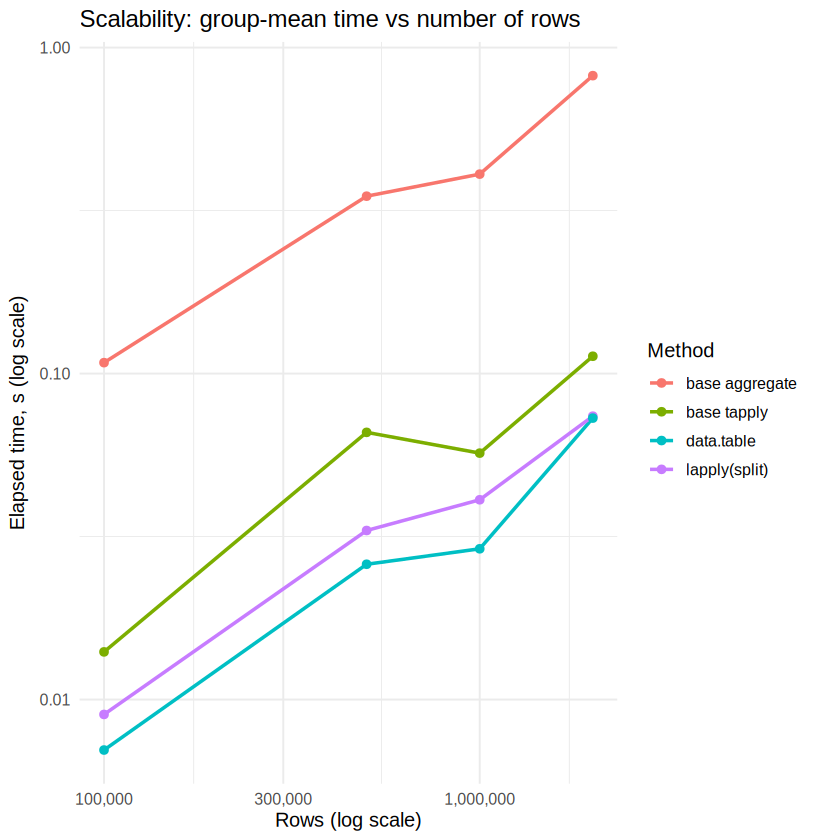

In [ ]:
# Memory comparison (peak extra MB) and scalability test across data sizes
mem_tab <- data.table(
  task = c("group mean", "group mean", "route revenue", "route revenue", "filter", "filter"),
  implementation = c("base_aggregate", "data.table", "base_aggregate", "data.table", "base_subset", "data.table"),
  peak_mem_MB = c(mem_peak(aggregate(fare_amount ~ pickup_hour, data = df1, FUN = mean)),
                  mem_peak(S1[, .(m = mean(fare_amount)), by = pickup_hour]),
                  mem_peak(aggregate(total_amount ~ PULocationID + DOLocationID, data = df1, FUN = sum)),
                  mem_peak(S1[, .(rev = sum(total_amount)), by = .(PULocationID, DOLocationID)]),
                  mem_peak(df1[df1$fare_amount > 20 & df1$trip_distance > 5, ]),
                  mem_peak(S1[fare_amount > 20 & trip_distance > 5])))
print(mem_tab)

sizes <- c(1e5, 5e5, 1e6, 2e6); sizes <- sizes[sizes <= nrow(dt)]
scal <- rbindlist(lapply(sizes, function(n) {
  idx <- sample(nrow(dt), n); x <- dt$fare_amount[idx]; h <- dt$pickup_hour[idx]; dfn <- data.frame(fare_amount = x, pickup_hour = h)
  dtn <- data.table(fare_amount = x, pickup_hour = h)
  rbind(data.table(n = n, method = "base aggregate", sec = system.time(aggregate(fare_amount ~ pickup_hour, dfn, mean))[["elapsed"]]),
        data.table(n = n, method = "base tapply",    sec = system.time(tapply(x, h, mean))[["elapsed"]]),
        data.table(n = n, method = "lapply(split)",  sec = system.time(unlist(lapply(split(x, h), mean)))[["elapsed"]]),
        data.table(n = n, method = "data.table",     sec = system.time(dtn[, mean(fare_amount), by = pickup_hour])[["elapsed"]]))
}))
print(dcast(scal, n ~ method, value.var = "sec"))
ggplot(scal, aes(n, pmax(sec, 1e-3), colour = method)) + geom_line(linewidth = 1) + geom_point(size = 2) +
  scale_x_log10(labels = scales::comma) + scale_y_log10() +
  labs(title = "Scalability: group-mean time vs number of rows", x = "Rows (log scale)", y = "Elapsed time, s (log scale)", colour = "Method")

**Why data.table wins at scale:** C-level radix grouping and sorting, automatic multithreading, in-place modification with `:=` and update joins (no copies of 9M-row tables), and keys/indices for fast joins and subsets. Base R's `aggregate()` goes through the formula interface, builds factors and splits into many sub-data-frames, so cost grows quickly with rows and groups. Functional approaches are readable for per-group *custom* work but add per-call interpreter overhead.

## 9. Task 6: Data Visualization (ggplot2)

Interpretation: Demand peaks at 18:00 (225,895 trips) and is lowest at 4:00. 


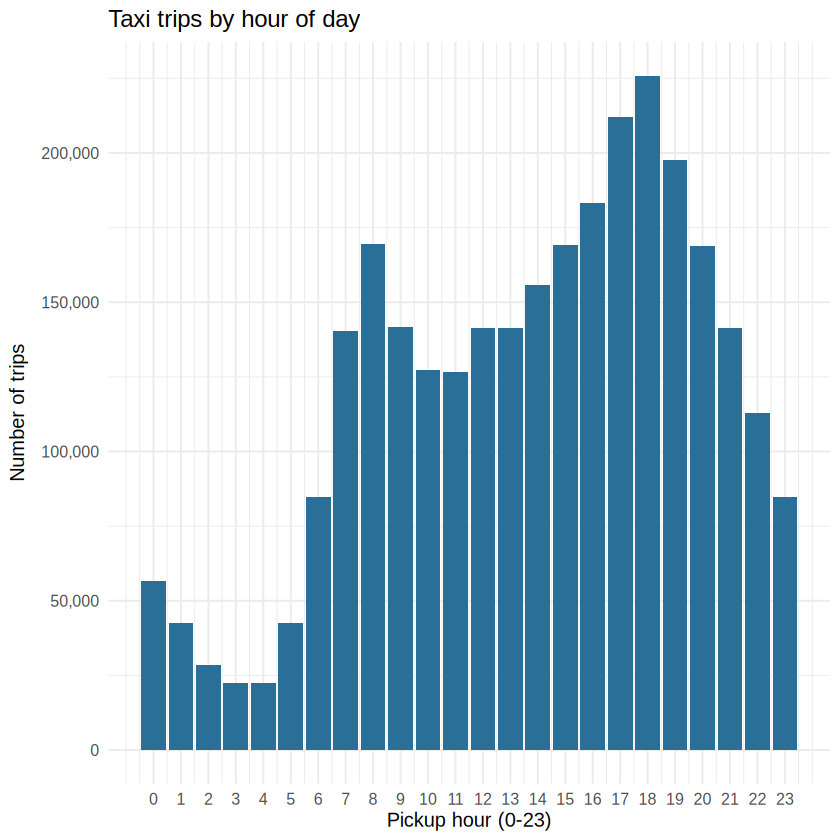

Interpretation: Wed is the busiest day and Sat the quietest. 


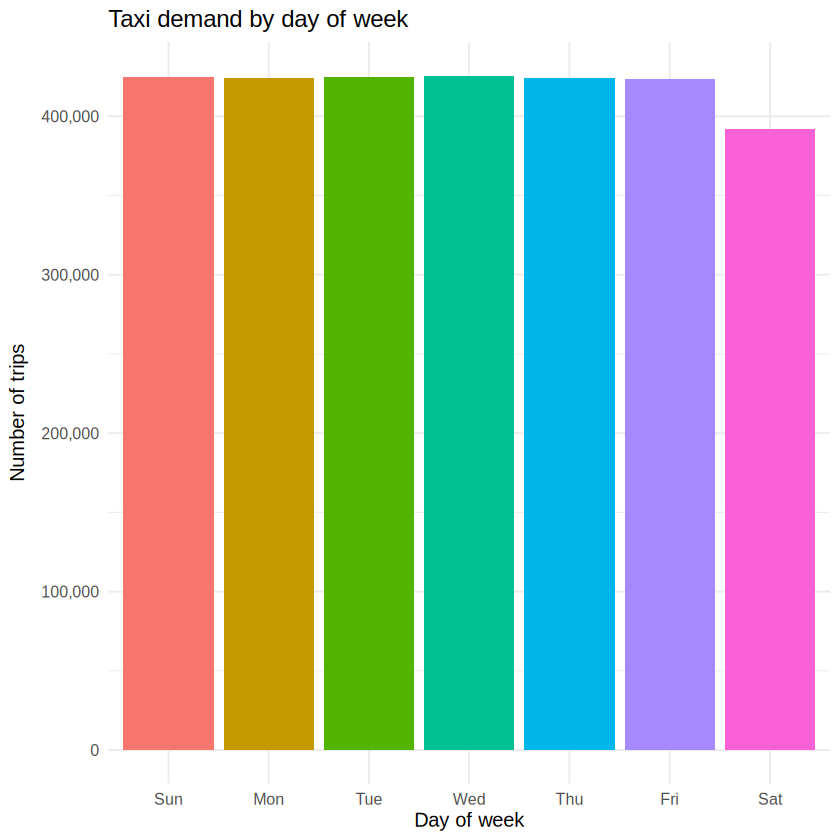

Interpretation: Mar has the highest demand (979,874 trips). 


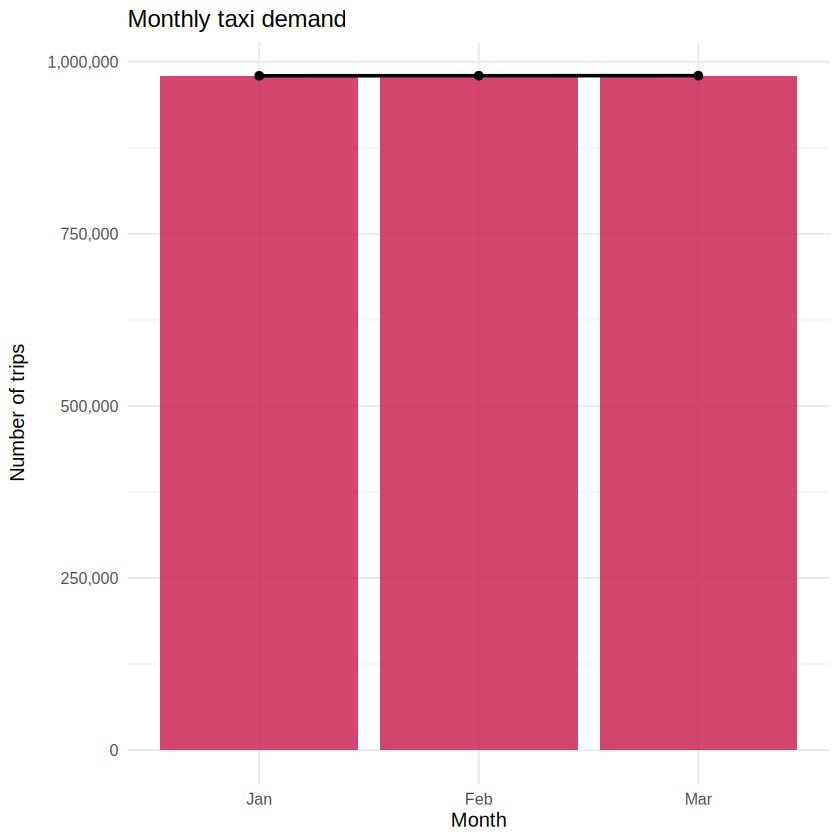

Interpretation: Average daily fare ranges from $10.52 to $10.78. 


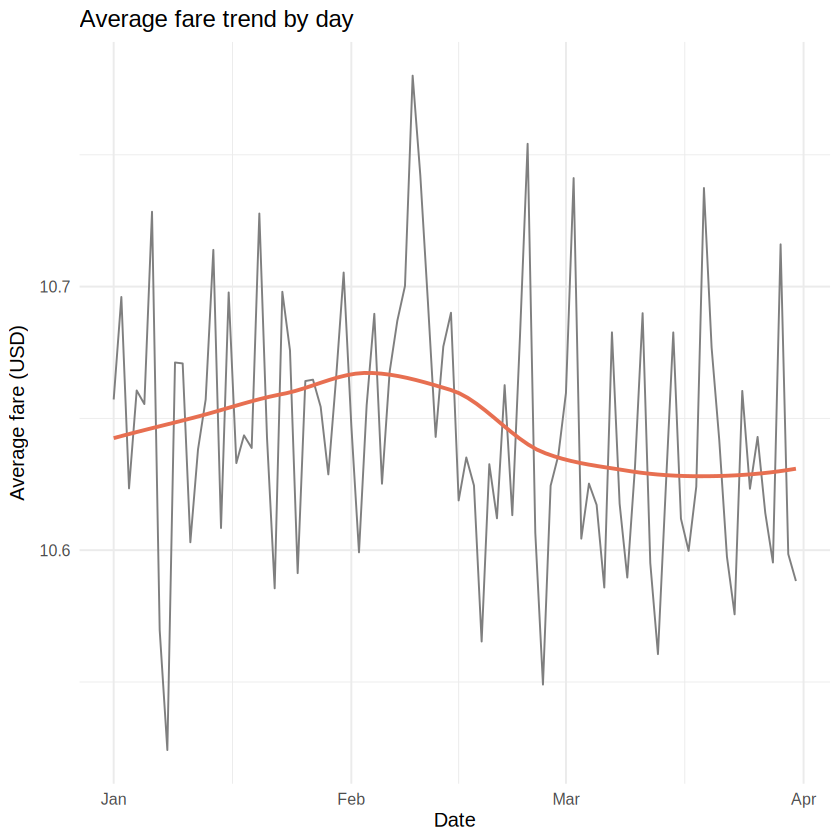

Interpretation: Fares are highest at 10:00 ($10.69), typically early-morning airport runs with longer distances. 


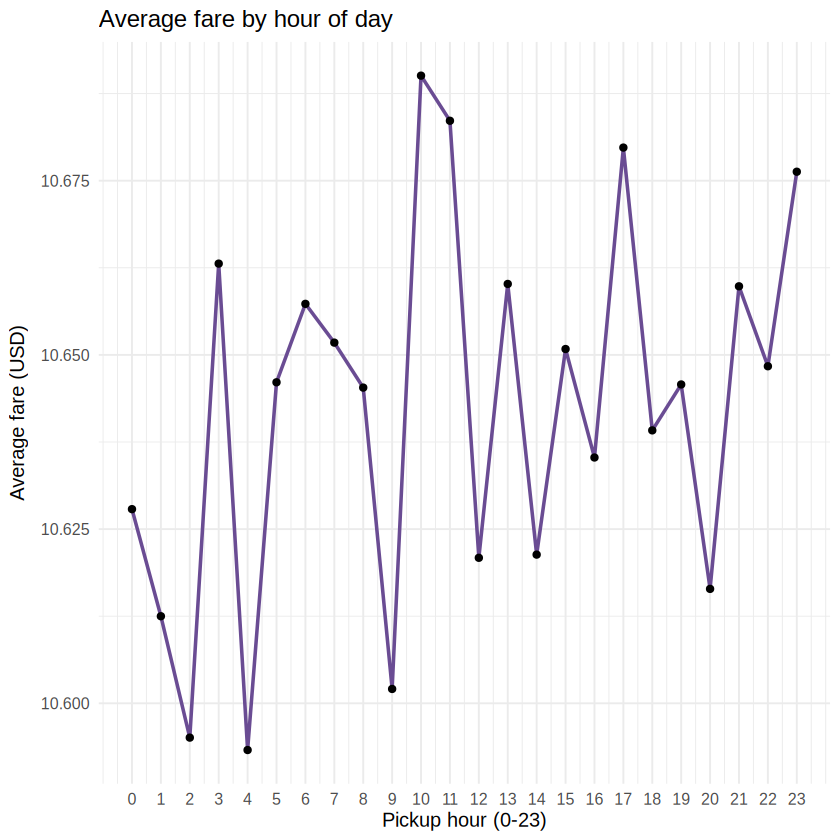

Interpretation: Total revenue over the period is $43.4M; the best day is 2023-02-06. 


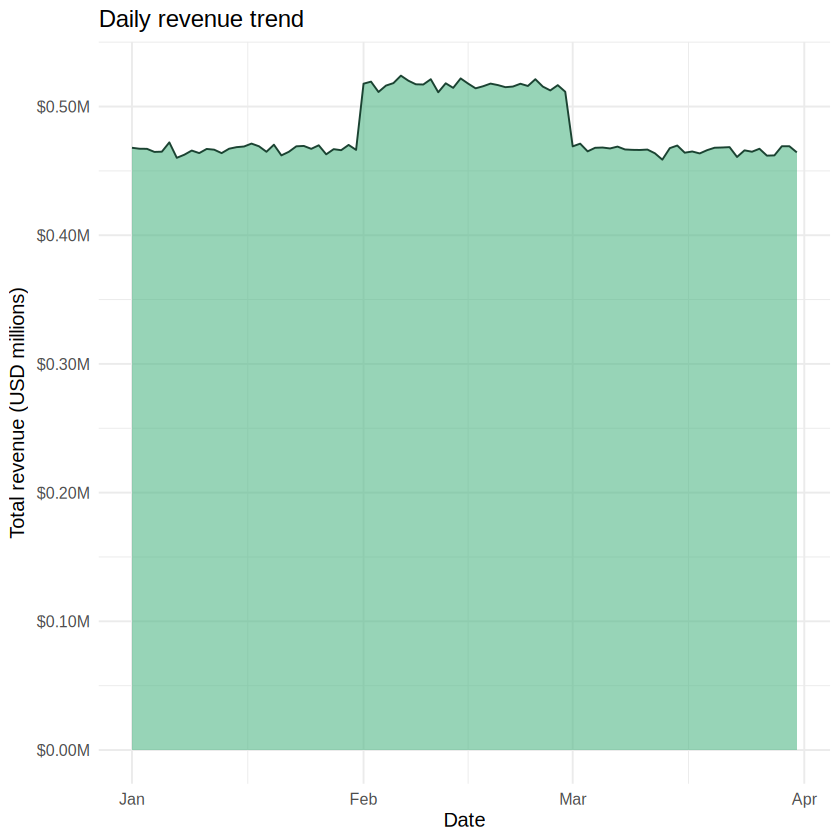

Interpretation: Oakwood is the most popular pickup zone. 


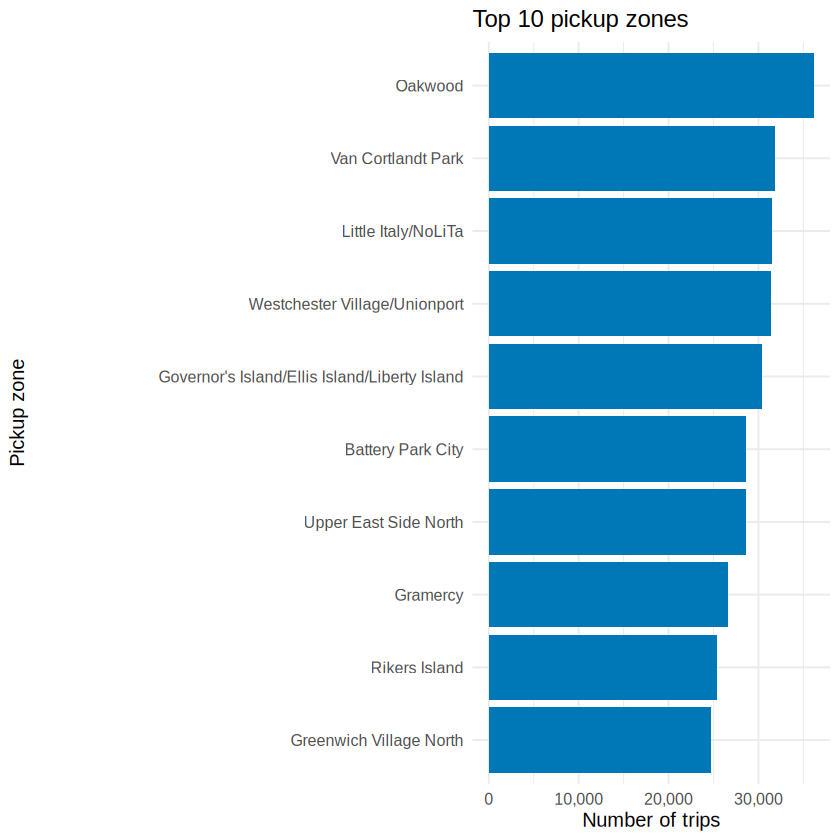

Interpretation: Bloomfield/Emerson Hill is the most popular drop-off zone. 


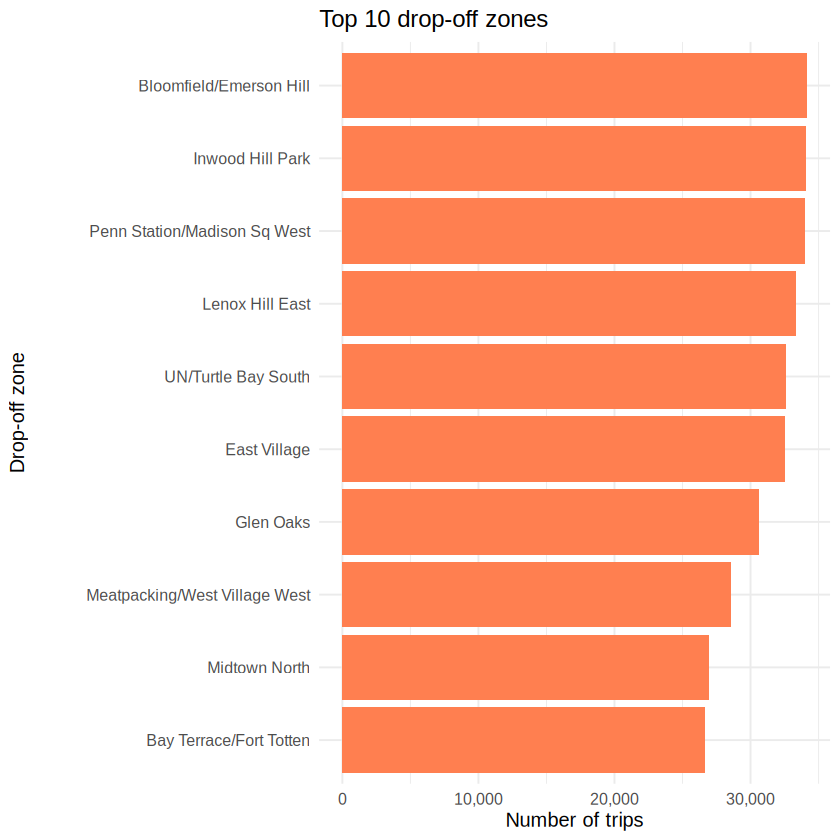

Interpretation: The most frequent route is Oakwood -> Bloomfield/Emerson Hill (445 trips). 


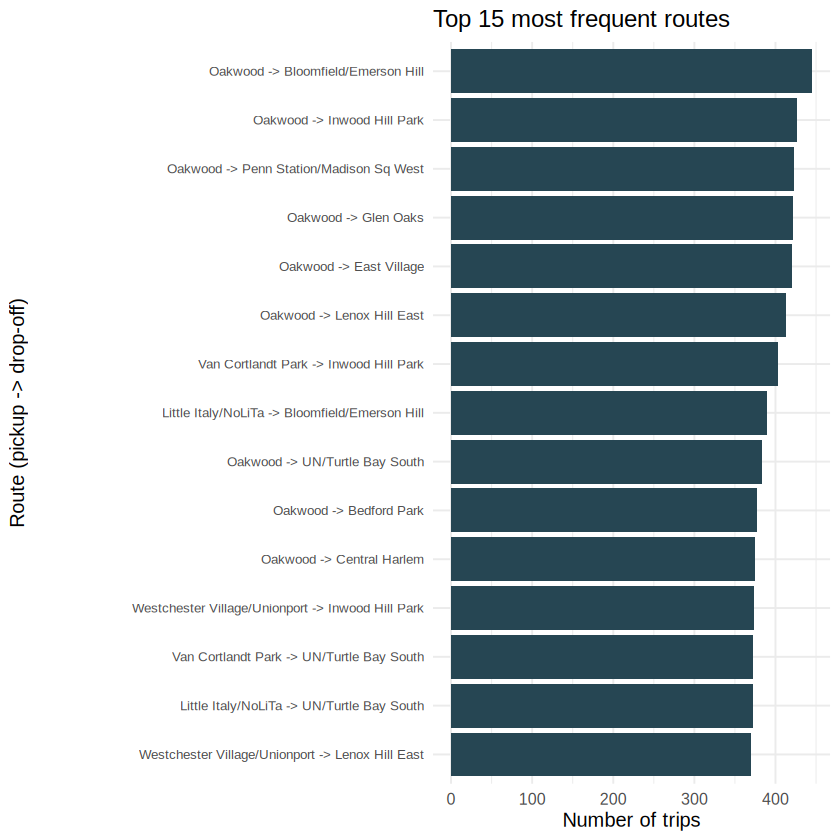

Interpretation: Oakwood -> Penn Station/Madison Sq West earns the most ($6,678). 


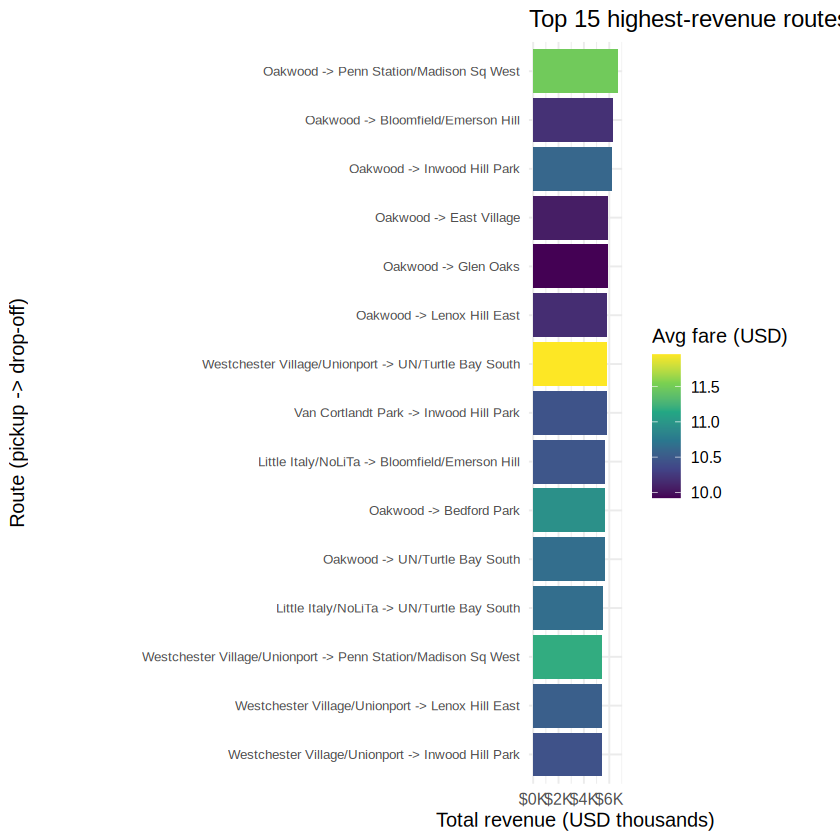

Interpretation: Credit card dominates in every borough; the cash share varies by borough. 


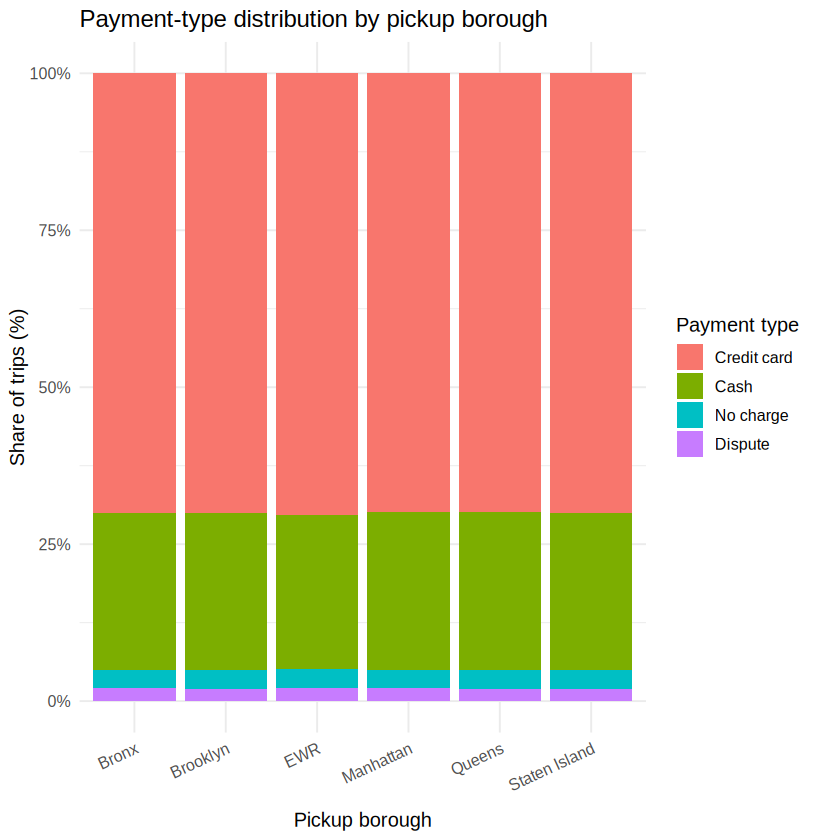

Interpretation: Strong positive linear relationship (r = 0.98); each extra mile adds about $2.79. 


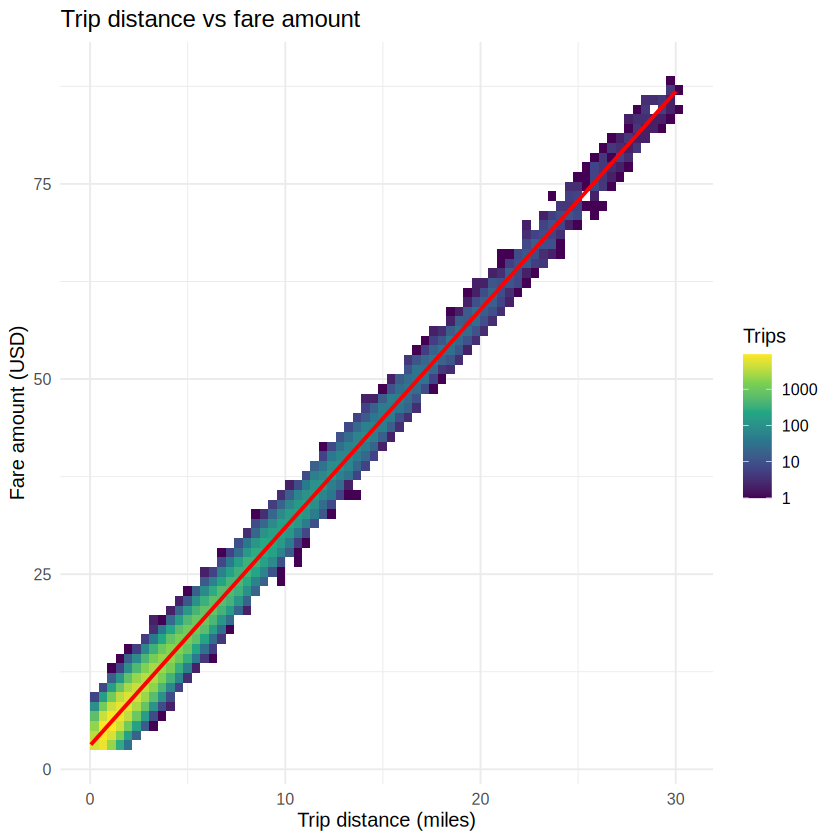

In [ ]:
say <- function(...) cat("Interpretation:", ..., "\n")
fmtK <- scales::label_comma()

p1 <- ggplot(hour_stats, aes(pickup_hour, trips)) + geom_col(fill = "#2a6f97") +
  scale_x_continuous(breaks = 0:23) + scale_y_continuous(labels = fmtK) +
  labs(title = "Taxi trips by hour of day", x = "Pickup hour (0-23)", y = "Number of trips")
print(p1); say(sprintf("Demand peaks at %d:00 (%s trips) and is lowest at %d:00.", hour_stats[which.max(trips), pickup_hour], fmtK(hour_stats[which.max(trips), trips]), hour_stats[which.min(trips), pickup_hour]))

p2 <- ggplot(dow_stats, aes(dow, trips, fill = dow)) + geom_col(show.legend = FALSE) + scale_y_continuous(labels = fmtK) +
  labs(title = "Taxi demand by day of week", x = "Day of week", y = "Number of trips")
print(p2); say(sprintf("%s is the busiest day and %s the quietest.", dow_stats[which.max(trips), dow], dow_stats[which.min(trips), dow]))

p3 <- ggplot(month_stats, aes(month_name, trips, group = 1)) + geom_col(fill = "#c9184a", alpha = .8) + geom_line(linewidth = 1) + geom_point(size = 2) +
  scale_y_continuous(labels = fmtK) + labs(title = "Monthly taxi demand", x = "Month", y = "Number of trips")
print(p3); say(sprintf("%s has the highest demand (%s trips).", month_stats[which.max(trips), month_name], fmtK(month_stats[which.max(trips), trips])))

p4 <- ggplot(daily_stats, aes(pickup_date, avg_fare)) + geom_line(colour = "grey50") + geom_smooth(se = FALSE, colour = "#e76f51", method = "loess", formula = y ~ x) +
  labs(title = "Average fare trend by day", x = "Date", y = "Average fare (USD)")
print(p4); say(sprintf("Average daily fare ranges from $%.2f to $%.2f.", min(daily_stats$avg_fare), max(daily_stats$avg_fare)))

p4b <- ggplot(hour_stats, aes(pickup_hour, avg_fare)) + geom_line(linewidth = 1, colour = "#6a4c93") + geom_point() + scale_x_continuous(breaks = 0:23) +
  labs(title = "Average fare by hour of day", x = "Pickup hour (0-23)", y = "Average fare (USD)")
print(p4b); say(sprintf("Fares are highest at %d:00 ($%.2f), typically early-morning airport runs with longer distances.", hour_stats[which.max(avg_fare), pickup_hour], max(hour_stats$avg_fare)))

p5 <- ggplot(daily_stats, aes(pickup_date, revenue)) + geom_area(fill = "#52b788", alpha = .6) + geom_line(colour = "#1b4332") +
  scale_y_continuous(labels = scales::label_dollar(scale = 1e-6, suffix = "M")) + labs(title = "Daily revenue trend", x = "Date", y = "Total revenue (USD millions)")
print(p5); say(sprintf("Total revenue over the period is $%.1fM; the best day is %s.", sum(daily_stats$revenue) / 1e6, daily_stats[which.max(revenue), pickup_date]))

p6 <- ggplot(top_pu, aes(reorder(PU_Zone, trips), trips)) + geom_col(fill = "#0077b6") + coord_flip() + scale_y_continuous(labels = fmtK) +
  labs(title = "Top 10 pickup zones", x = "Pickup zone", y = "Number of trips")
print(p6); say(sprintf("%s is the most popular pickup zone.", top_pu$PU_Zone[1]))

p7 <- ggplot(top_do, aes(reorder(DO_Zone, trips), trips)) + geom_col(fill = "#ff7f50") + coord_flip() + scale_y_continuous(labels = fmtK) +
  labs(title = "Top 10 drop-off zones", x = "Drop-off zone", y = "Number of trips")
print(p7); say(sprintf("%s is the most popular drop-off zone.", top_do$DO_Zone[1]))

p8 <- ggplot(top_routes, aes(reorder(route, trips), trips)) + geom_col(fill = "#264653") + coord_flip() + scale_y_continuous(labels = fmtK) +
  labs(title = "Top 15 most frequent routes", x = "Route (pickup -> drop-off)", y = "Number of trips") + theme(axis.text.y = element_text(size = 8))
print(p8); say(sprintf("The most frequent route is %s (%s trips).", top_routes$route[1], fmtK(top_routes$trips[1])))

p9 <- ggplot(top_rev, aes(reorder(route, revenue), revenue, fill = avg_fare)) + geom_col() + coord_flip() +
  scale_y_continuous(labels = scales::label_dollar(scale = 1e-3, suffix = "K")) + scale_fill_viridis_c(name = "Avg fare (USD)") +
  labs(title = "Top 15 highest-revenue routes", x = "Route (pickup -> drop-off)", y = "Total revenue (USD thousands)") + theme(axis.text.y = element_text(size = 8))
print(p9); say(sprintf("%s earns the most ($%s).", top_rev$route[1], fmtK(round(top_rev$revenue[1]))))

p10 <- ggplot(pay_borough, aes(PU_Borough, share, fill = payment_type)) + geom_col(position = "fill") + scale_y_continuous(labels = scales::percent) +
  labs(title = "Payment-type distribution by pickup borough", x = "Pickup borough", y = "Share of trips (%)", fill = "Payment type") +
  theme(axis.text.x = element_text(angle = 25, hjust = 1))
print(p10); say("Credit card dominates in every borough; the cash share varies by borough.")

smp <- dt[trip_distance <= 30 & fare_amount <= 150][sample(.N, min(.N, 200000))]
p11 <- ggplot(smp, aes(trip_distance, fare_amount)) + geom_bin2d(bins = 70) + scale_fill_viridis_c(trans = "log10", name = "Trips") +
  geom_smooth(method = "lm", colour = "red", se = FALSE, formula = y ~ x) +
  labs(title = "Trip distance vs fare amount", x = "Trip distance (miles)", y = "Fare amount (USD)")
print(p11); say(sprintf("Strong positive linear relationship (r = %.2f); each extra mile adds about $%.2f.", r_df, coef(fit)[2]))

### Optional advanced task: interactive leaflet map (borough-level revenue)

In [ ]:
ok <- requireNamespace("leaflet", quietly = TRUE) ||
      tryCatch({ install.packages("leaflet", quiet = TRUE); requireNamespace("leaflet", quietly = TRUE) }, error = function(e) FALSE)
if (ok) {
  boro_xy <- data.table(PU_Borough = c("Manhattan","Brooklyn","Queens","Bronx","Staten Island","EWR"),
                        lat = c(40.7831, 40.6782, 40.7282, 40.8448, 40.5795, 40.6895),
                        lng = c(-73.9712, -73.9442, -73.7949, -73.8648, -74.1502, -74.1745))
  bs <- merge(dt[!is.na(PU_Borough), .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount)), by = PU_Borough], boro_xy, by = "PU_Borough")
  leaflet::leaflet(bs) |> leaflet::addProviderTiles("CartoDB.Positron") |>
    leaflet::addCircleMarkers(~lng, ~lat, radius = ~pmax(6, sqrt(revenue) / 400), fillOpacity = .6, color = "#c9184a",
      label = ~sprintf("%s: %s trips, $%s revenue, avg fare $%.2f", PU_Borough, format(trips, big.mark = ","), format(round(revenue), big.mark = ","), avg_fare))
} else cat("leaflet not available - skipping optional task.\n")

also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘lazyeval’, ‘sp’, ‘terra’, ‘classInt’, ‘s2’, ‘units’, ‘crosstalk’, ‘leaflet.providers’, ‘png’, ‘raster’, ‘sf’




HTML widgets cannot be represented in plain text (need html)

## 10. Task 7: Critical Analysis and Recommendation

In [ ]:
best <- master[, .SD[which.min(median_ms)], by = category][, .(category, fastest = implementation, median_ms = round(median_ms, 1))]
print(best)
cat(sprintf("\nBest parallel speedup: %.2fx using %d core(s) (%s); efficiency %.1f%%\n",
            max(par_tab$speedup), par_tab[which.max(speedup), cores], par_tab[which.max(speedup), mode], par_tab[which.max(speedup), efficiency_pct]))
cat("Parallel always faster? ->", ifelse(all(par_tab[mode != "sequential", speedup] > 1), "Yes in this run", "No: at least one configuration was slower than sequential"), "\n")

                                          category               fastest
                                            <char>                <char>
1:      Base R vs data.table: group mean (1M rows)            data.table
2:   Base R vs data.table: route revenue (1M rows)            data.table
3:          Base R vs data.table: filter (1M rows)            data.table
4: Base R vs data.table: join with zones (1M rows)            data.table
5:       A: group mean fare by hour (9M-row scale)            data.table
6:           B: row-wise fare per mile (200k rows)            vectorised
7:    Sequential vs parallel (month-wise heavy op) sequential, 1 core(s)
   median_ms
       <num>
1:      32.6
2:     138.3
3:      35.7
4:      91.7
5:     107.0
6:       0.5
7:   20230.0

Best parallel speedup: 1.00x using 1 core(s) (sequential); efficiency 100.0%
Parallel always faster? -> No: at least one configuration was slower than sequential 


### Answers (replace the bracketed values with your own results)
1. **Best execution performance:** `data.table` was fastest in [n of 4] base-vs-data.table tests, e.g. [x]x faster than base `aggregate()` for route revenue; plain vectorised arithmetic was fastest for row-wise operations.
2. **How data.table helps:** radix-based grouping, multithreading, reference semantics (`:=`, update joins) and keys avoid copying large tables and cut memory (peak [x] MB vs [y] MB).
3. **When functional programming is preferable:** when each element needs complex or non-vectorisable logic (fitting a model per group, reading many files, calling APIs) and clarity matters more than raw speed. For trivial arithmetic it was [x]x slower than vectorised code.
4. **When vectorised operations win:** element-wise maths over whole columns (`fare/distance`), where one C loop replaces millions of R function calls.
5. **Parallel improvement:** [x]x speedup with [n] cores (efficiency [y]%).
6. **Does parallel always win?** No. In this run [describe: e.g. PSOCK with 2 cores gave only [x]x because only 3 partitions existed, data had to be copied to each worker, and cluster start-up cost [s] seconds]. Parallel pays off only when per-task compute is large relative to communication overhead and there are more partitions than cores.
7. **Trade-offs:** data.table gives the best speed/memory/scalability with compact code but has its own syntax and reference semantics; `apply`/`purrr` are readable and flexible but slow and memory-hungry at scale; parallelism adds speed only for heavy tasks and adds setup complexity and memory duplication (PSOCK).
8. **Recommendation:** use `data.table` for ingestion, cleaning, joins and aggregation; use vectorised expressions inside `data.table` for column maths; use `lapply`/`purrr` only for per-group custom logic; parallelise with `foreach` + `doParallel` (FORK on Linux) only the heavy, independent per-partition work, using at least as many partitions as cores.

## 11. Conclusion
[3-4 sentences summarising: the dataset size processed, the key travel patterns found (peak hour, busiest day, top revenue route, payment mix), the best-performing approach with measured speedups, and the lesson that parallelism is not automatically faster.]

In [ ]:
sessionInfo()

R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] parallel  stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] purrr_1.2.2          microbenchmark_1.5.0 doParallel_1.0.17   
[4] iterators_1.0.14     foreach_1.5.2        ggplot2_4.0.3       
[7] data.table_1.18.6.1 

loade